# 04｜Transformer 组件对比：位置编码与 Head

这一页坚持单变量对照：数据、seed、模型宽度、层数、优化器和训练轮数保持一致。主对照只开关位置编码；次对照只改变 Head 数。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "transformer_lab").is_dir():
    LAB_DIR = (LAB_DIR / "04_transformer_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

torch.set_num_threads(1)

from transformer_lab import compare, evaluate_length_transfer, plot_comparison, print_result_table


## 运行前预测

先写下预测再运行：

1. 关闭位置编码后，Accuracy 会 __，因为 __。
2. 1、2、4 个 Head 中，我预测 __ 较高；理由是 __。
3. “更多 Head”是否必然更好？__。

三种颜色总数相同，所以无位置编码模型不能通过颜色计数识别第 0 位。

实验                          测试Acc       参数量     更新        组合预算       秒
有位置编码｜4 Heads               99.7%     8,771    228   2,433,600    0.98
无位置编码｜4 Heads               33.3%     8,771    228   2,433,600    0.96
有位置编码｜1 Head                66.7%     8,771    228   2,433,600    0.75
有位置编码｜2 Heads              100.0%     8,771    228   2,433,600    0.81


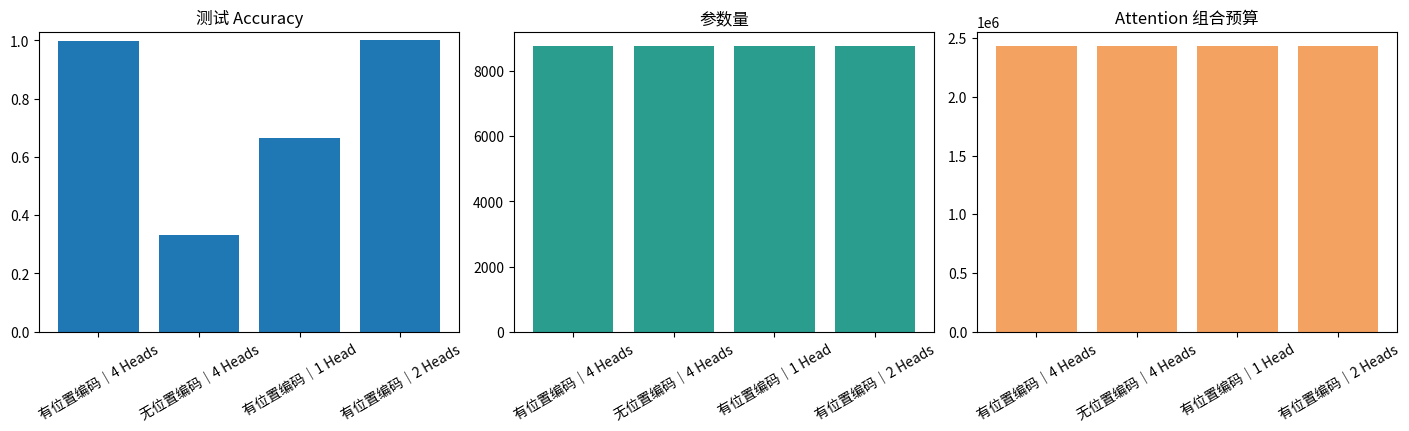

In [2]:
DEVICE = "cpu"
# 四组共用默认 1200/300/300 数据、12 Epoch 和 seed=42。
results = compare(epochs=12, seed=42, device=DEVICE)


## 公平比较检查表

- 有位置 vs 无位置：只改变 `use_positional_encoding`；
- 1/2/4 Head：只改变 `num_heads`，并保持 `d_model=32`；
- 相同 `d_model` 下 Head 数变化不会明显改变总参数量；
- 一次 seed 的排序不能推广成“某种 Head 永远最好”。

把运行结果填入下表。

| 实验 | 我的预测 | 唯一修改 | 测试 Accuracy | 参数量 | Attention 预算 | 图形证据 |
|---|---|---|---:|---:|---:|---|
| 有位置，4 Head |  | 基线 |  |  |  |  |
| 无位置，4 Head |  | 位置编码关闭 |  |  |  |  |
| 有位置，1 Head |  | Head 4→1 |  |  |  |  |
| 有位置，2 Head |  | Head 4→2 |  |  |  |  |

## 可选：长度迁移，不重新训练

下面把每个已训练模型直接放到内容长度 24 的新测试集。它回答的是“当前模型能否迁移”，不是在长序列上重新训练后的成绩。

In [3]:
for result in results:
    transfer = evaluate_length_transfer(result, content_length=24, test_size=300)
    print(f"{result['config'].name:<24} 长度24 Accuracy = {transfer['accuracy']:.1%}")


有位置编码｜4 Heads            长度24 Accuracy = 92.7%
无位置编码｜4 Heads            长度24 Accuracy = 33.3%
有位置编码｜1 Head             长度24 Accuracy = 41.0%
有位置编码｜2 Heads            长度24 Accuracy = 75.7%


## 可选随机种子复核

课堂默认不再运行四组训练。只有教师统一安排或机器空闲时才打开。

In [4]:
RUN_SEED_CHECK = False
if RUN_SEED_CHECK:
    second_results = compare(epochs=12, seed=7, device=DEVICE)
    print_result_table(second_results)
    plot_comparison(second_results)
else:
    print("未运行额外四组训练。需要复核时再改为 True。")


未运行额外四组训练。需要复核时再改为 True。


## 有边界的结论模板

“在本次平衡颜色任务、长度 12、seed=42 和固定训练预算下，关闭位置编码后 __；Head 数从 __ 改为 __ 后 __。这些结果说明 __，但不能说明 __。”

## 完成本页后：释放资源并结束内核

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)
